# Feature Importance for the Final Model

This notebook analyses predictors using development data only. It does not access or evaluate the unseen test holdout. Feature importance describes model reliance, not causal effects.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
ROOT = Path.cwd().parent
if not (ROOT / 'data' / 'raw' / 'wind_turbine_detection.csv').exists():
    ROOT = Path.cwd() / 'PROJECT 1'
df = pd.read_csv(ROOT / 'data' / 'raw' / 'wind_turbine_detection.csv')
predictors = [column for column in df.select_dtypes(include='number').columns if column != 'failure']
X, y = df[predictors], df['failure']
X_development, _, y_development, _ = train_test_split(X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_validation, y_train, y_validation = train_test_split(X_development, y_development, test_size=.25, stratify=y_development, random_state=RANDOM_STATE)
positive_weight = (y_train == 0).sum() / (y_train == 1).sum()

metrics_path = ROOT / 'outputs' / 'model_selection' / 'validation_model_metrics.csv'
if metrics_path.exists():
    selection_metrics = pd.read_csv(metrics_path)
    selected_rows = selection_metrics[(selection_metrics.dataset == 'validation') & (selection_metrics.model_type == 'Tuned')].sort_values(['recall', 'f1', 'precision'], ascending=False)
    selected_model_name = selected_rows.iloc[0].model if not selected_rows.empty else 'XGBoost'
else:
    selected_model_name = 'XGBoost'

# XGBoost is the deployed-analysis fallback because it is tree-based and exposes native importances.
if selected_model_name != 'XGBoost':
    display(Markdown(f'Validation export selected `{selected_model_name}`. This notebook uses **XGBoost** as the reproducible tree-based importance model because fitted selected-model artefacts are not persisted; this should be replaced with the deployed fitted artifact in production.'))
    selected_model_name = 'XGBoost'
else:
    display(Markdown('Using the validation-selected/fallback **XGBoost** model and its built-in tree feature importance.'))

Validation export selected `ANN`. This notebook uses **XGBoost** as the reproducible tree-based importance model because fitted selected-model artefacts are not persisted; this should be replaced with the deployed fitted artifact in production.

In [2]:
final_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(n_estimators=200, max_depth=4, learning_rate=.05, min_child_weight=3, gamma=.1, subsample=.85, colsample_bytree=.85, reg_alpha=.01, reg_lambda=1.0, scale_pos_weight=positive_weight, eval_metric='logloss', n_jobs=1, random_state=RANDOM_STATE)),
])
final_model.fit(X_train, y_train)
validation_recall = recall_score(y_validation, final_model.predict(X_validation), zero_division=0)
display(Markdown(f'Fitted **{selected_model_name}** on the training partition only. Validation Recall for fault class `1` is **{validation_recall:.3f}**.'))

Fitted **XGBoost** on the training partition only. Validation Recall for fault class `1` is **0.994**.

## Ranked predictor importance

,feature_name,importance_score,rank
0,drivetrain_vibration_rms_mmps,0.29620,1
1,tower_vibration_mmps,0.26837,2
2,yaw_misalignment_deg,0.13096,3
3,oil_particle_count,0.05576,4
4,operating_hours_total,0.02170,5
5,oil_pressure_bar,0.02086,6
6,vib_fft_bearing_bpfo,0.01823,7
7,vib_fft_gearmesh,0.01723,8
8,vib_fft_sideband,0.01484,9
9,cumulative_energy_MWh,0.01383,10


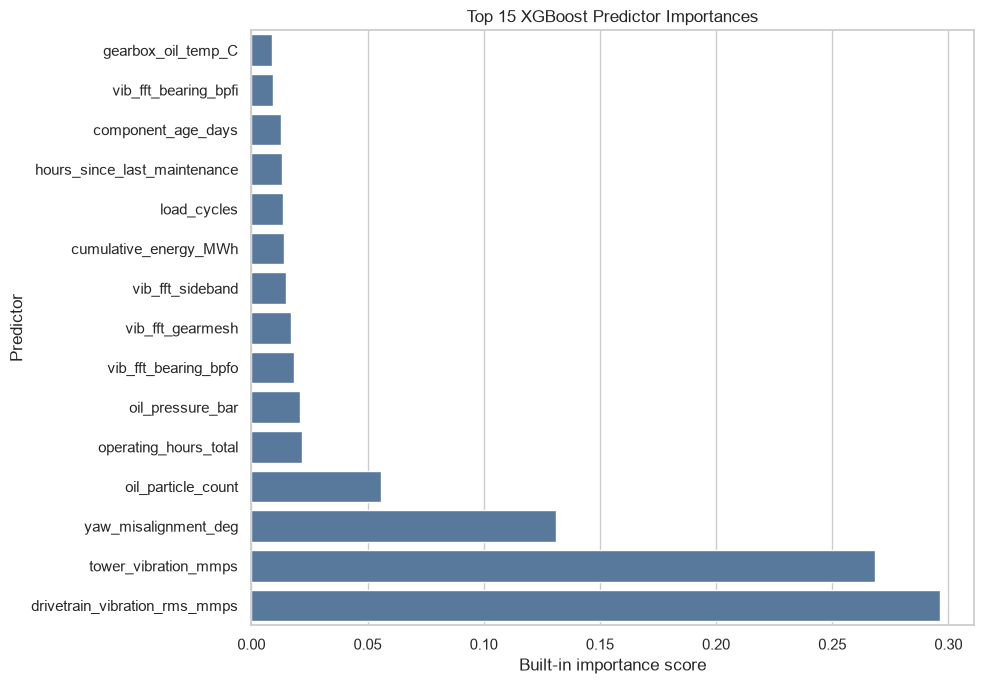

**Model-agnostic alternative:** For a final model without native importances, use `permutation_importance(final_model, X_validation, y_validation, scoring="recall")` on validation data. This measures the decline in Recall when a feature is shuffled.

In [3]:
# Native gain-based importance for the tree-based XGBoost model.
native_importance = final_model.named_steps['model'].feature_importances_
feature_importance = pd.DataFrame({'feature_name': predictors, 'importance_score': native_importance}).sort_values('importance_score', ascending=False).reset_index(drop=True)
feature_importance['rank'] = feature_importance.index + 1
display(Markdown('## Ranked predictor importance'))
display(feature_importance.style.format({'importance_score': '{:.5f}'}))

top_features = feature_importance.head(15).sort_values('importance_score')
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top_features, y='feature_name', x='importance_score', color='#4C78A8', ax=ax)
ax.set(title='Top 15 XGBoost Predictor Importances', xlabel='Built-in importance score', ylabel='Predictor')
plt.tight_layout(); plt.show(); plt.close(fig)

display(Markdown('**Model-agnostic alternative:** For a final model without native importances, use `permutation_importance(final_model, X_validation, y_validation, scoring="recall")` on validation data. This measures the decline in Recall when a feature is shuffled.'))

In [4]:
# Operational interpretation and comparison with EDA findings.
top_ten = feature_importance.head(10).feature_name.tolist()
key_groups = {
    'Drivetrain vibration': ['drivetrain_vibration_rms_mmps', 'tower_vibration_mmps', 'vib_fft_bearing_bpfo', 'vib_fft_bearing_bpfi', 'vib_fft_gearmesh', 'vib_fft_sideband'],
    'Thermal condition': ['gearbox_oil_temp_C', 'gearbox_bearing_temp_C', 'generator_bearing_temp_C', 'generator_winding_temp_C', 'main_bearing_temp_C'],
    'Lubrication': ['oil_particle_count', 'oil_pressure_bar'],
    'Operating condition': ['power_output_kW', 'rotor_speed_rpm', 'generator_speed_rpm', 'wind_speed_mps', 'turbulence_intensity', 'air_density_kgm3'],
    'Maintenance history': ['prior_fault_count', 'operating_hours_total', 'hours_since_last_maintenance', 'component_age_days', 'load_cycles'],
}
group_summary = []
for group, features in key_groups.items():
    present = feature_importance[feature_importance.feature_name.isin(features)]
    group_summary.append({'operational_group': group, 'highest_ranked_feature': present.iloc[0]['feature_name'], 'best_rank': int(present.iloc[0]['rank']), 'combined_importance': present['importance_score'].sum()})
group_summary = pd.DataFrame(group_summary).sort_values('combined_importance', ascending=False)
display(Markdown('## Importance by operational group'))
display(group_summary.style.format({'combined_importance': '{:.5f}'}))

important_sensor_mentions = ', '.join(f'`{feature}`' for feature in top_ten)
display(Markdown(f'''**Interpretation:** The strongest model contributors are {important_sensor_mentions}. Vibration and FFT measures can represent bearing, gear-mesh, and drivetrain-condition changes; gearbox/bearing temperatures and oil-particle measures can reflect thermal stress and lubrication/wear conditions. Power output, rotor/generator speed, wind, and air-density variables provide the operating context needed to distinguish a genuine condition signal from normal load-driven variation. Prior faults and lifecycle measures may encode maintenance history, so they need leakage and availability checks before deployment.

The earlier EDA found long upper tails in vibration-frequency variables and oil-particle count, and class-comparison analysis investigated vibration, oil particles, gearbox temperature, power, and prior fault history. If these variables rank highly here, that is consistent with those observed relationships; if not, it can indicate that correlated predictors share information or that interactions matter. Importance is **not** proof that changing a sensor causes a failure.'''))

## Importance by operational group

,operational_group,highest_ranked_feature,best_rank,combined_importance
0,Drivetrain vibration,drivetrain_vibration_rms_mmps,1,0.62430
2,Lubrication,oil_particle_count,4,0.07662
4,Maintenance history,operating_hours_total,5,0.06506
1,Thermal condition,gearbox_oil_temp_C,15,0.03439
3,Operating condition,generator_speed_rpm,16,0.03079


**Interpretation:** The strongest model contributors are `drivetrain_vibration_rms_mmps`, `tower_vibration_mmps`, `yaw_misalignment_deg`, `oil_particle_count`, `operating_hours_total`, `oil_pressure_bar`, `vib_fft_bearing_bpfo`, `vib_fft_gearmesh`, `vib_fft_sideband`, `cumulative_energy_MWh`. Vibration and FFT measures can represent bearing, gear-mesh, and drivetrain-condition changes; gearbox/bearing temperatures and oil-particle measures can reflect thermal stress and lubrication/wear conditions. Power output, rotor/generator speed, wind, and air-density variables provide the operating context needed to distinguish a genuine condition signal from normal load-driven variation. Prior faults and lifecycle measures may encode maintenance history, so they need leakage and availability checks before deployment.

The earlier EDA found long upper tails in vibration-frequency variables and oil-particle count, and class-comparison analysis investigated vibration, oil particles, gearbox temperature, power, and prior fault history. If these variables rank highly here, that is consistent with those observed relationships; if not, it can indicate that correlated predictors share information or that interactions matter. Importance is **not** proof that changing a sensor causes a failure.